In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix

class LogisticTorch:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):
        X_t = torch.from_numpy(X).float()
        y_t = torch.from_numpy(y).float().unsqueeze(1)

        n_samples, n_features = X_t.shape
        # Initialize parameters
        self.weights = torch.zeros((n_features, 1), requires_grad=True)
        self.bias = torch.zeros(1, requires_grad=True)

        optimizer = optim.SGD([self.weights, self.bias], lr=self.lr)
        loss_fn = nn.BCEWithLogitsLoss()

        for epoch in range(self.epochs):
            optimizer.zero_grad()
            logits = X_t @ self.weights + self.bias
            loss = loss_fn(logits, y_t)
            loss.backward()
            optimizer.step()

            self.loss_history.append(loss.item())

    def predict_proba(self, X):
        X_t = torch.from_numpy(X).float()
        logits = X_t @ self.weights + self.bias
        probs = torch.sigmoid(logits).detach().numpy()
        return np.hstack([1 - probs, probs])

    def predict(self, X):
        probs = self.predict_proba(X)[:,1]
        return (probs >= 0.5).astype(int)



 classification report:
LogisticTorch: 
               precision    recall  f1-score   support

           0       0.82      0.84      0.83       100
           1       0.84      0.81      0.82       100

    accuracy                           0.82       200
   macro avg       0.83      0.82      0.82       200
weighted avg       0.83      0.82      0.82       200

sklearn LogisticRegression:
               precision    recall  f1-score   support

           0       0.84      0.87      0.85       100
           1       0.86      0.83      0.85       100

    accuracy                           0.85       200
   macro avg       0.85      0.85      0.85       200
weighted avg       0.85      0.85      0.85       200



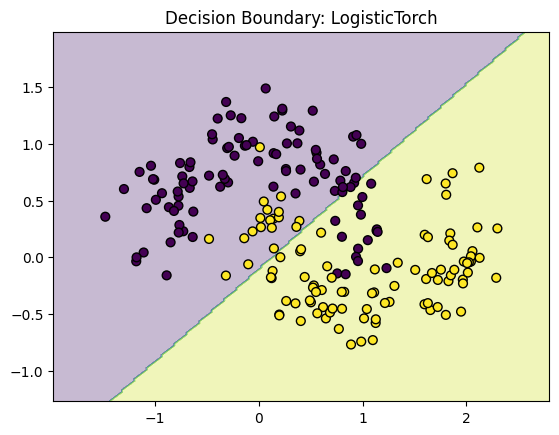

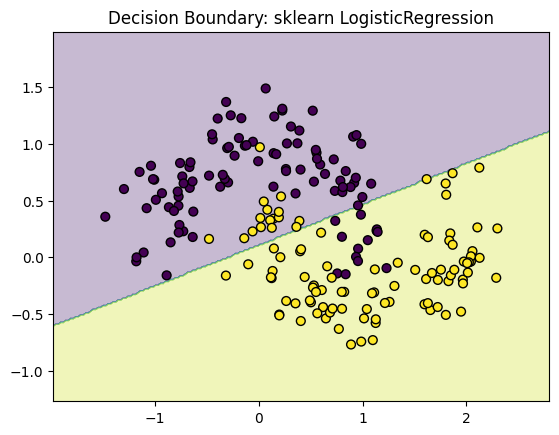

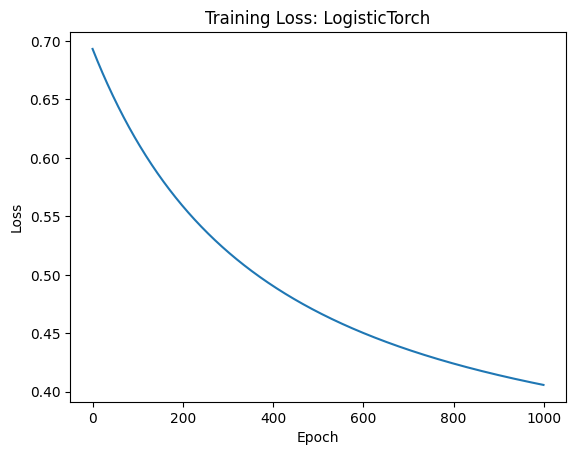

LogisticTorch acc: 0.825
sklearn LogisticRegression acc: 0.85


In [3]:
X, y = make_moons(n_samples=200, noise=0.2, random_state=42)

# Train our PyTorch logistic
model = LogisticTorch()
model.fit(X, y)
y_pred_torch = model.predict(X)

# Train sklearn logistic
sk_model = LogisticRegression()
sk_model.fit(X, y)
y_pred_sk = sk_model.predict(X)


print("\n classification report:")
print("LogisticTorch: \n", classification_report(y, y_pred_torch))
print("sklearn LogisticRegression:\n",classification_report(y, y_pred_sk))


def plot_decision_boundary(clf, X, y, title):
    x_min, x_max = X[:,0].min() - 0.5, X[:,0].max() + 0.5
    y_min, y_max = X[:,1].min() - 0.5, X[:,1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = clf.predict(grid).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, s=40, edgecolor='k')
    plt.title(title)
    plt.show()

plot_decision_boundary(model, X, y, "Decision Boundary: LogisticTorch")
plot_decision_boundary(sk_model, X, y, "Decision Boundary: sklearn LogisticRegression")

# Plot loss curve
plt.figure()
plt.plot(model.loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss: LogisticTorch")
plt.show()

# accuracy
acc_torch = accuracy_score(y, y_pred_torch)
acc_sk = accuracy_score(y, y_pred_sk)
print("LogisticTorch acc:", acc_torch)
print("sklearn LogisticRegression acc:", acc_sk)
